## 2026 NFL Fantasy Rankings Project Part 3 - RB Rankings

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
%matplotlib inline

C:\Users\kevin\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\kevin\anaconda3\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
C:\Users\kevin\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"


In [29]:
final_rb = pd.read_csv('../outputs/final_rbs_model_data_2020_2026.csv')

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.utils import resample

In [4]:
pd.set_option('display.max_columns', None)

In [5]:
pd.set_option('display.max_rows', None)

In [6]:
print(final_rb.columns.tolist())

['preseason_rank', 'player_name', 'season', 'past_season', 'player_age', 'team', 'team_qb', 'team_qb_season', 'team_qb_age', 'teammate', 'teammate_season', 'teammate_age', 'player_display_name', 'fantasy_points_ppr_pg', 'Previous_player_display_name', 'Previous_season', 'Previous_carries_pg', 'Previous_rushing_yards_pg', 'Previous_rushing_tds_pg', 'Previous_rushing_fumbles_pg', 'Previous_rushing_fumbles_lost_pg', 'Previous_rushing_first_downs_pg', 'Previous_rushing_2pt_conversions_pg', 'Previous_rushing_10_pg', 'Previous_rushing_12_pg', 'Previous_rushing_20_pg', 'Previous_rushing_40_pg', 'Previous_rushing_epa_pg', 'Previous_receptions_pg', 'Previous_targets_pg', 'Previous_receiving_yards_pg', 'Previous_receiving_tds_pg', 'Previous_receiving_fumbles_pg', 'Previous_receiving_fumbles_lost_pg', 'Previous_receiving_air_yards_pg', 'Previous_receiving_yards_after_catch_pg', 'Previous_receiving_first_downs_pg', 'Previous_receiving_2pt_conversions_pg', 'Previous_receiving_10_pg', 'Previous_rece

In [7]:
predictors = ['player_age', 'team_qb_age', 'teammate_age', 'Previous_carries_pg', 
              'Previous_rushing_yards_pg', 'Previous_rushing_tds_pg', 'Previous_rushing_fumbles_pg', 
              'Previous_rushing_fumbles_lost_pg', 'Previous_rushing_first_downs_pg', 
              'Previous_rushing_2pt_conversions_pg', 'Previous_rushing_10_pg', 'Previous_rushing_12_pg', 
              'Previous_rushing_20_pg', 'Previous_rushing_40_pg', 'Previous_rushing_epa_pg', 
              'Previous_receptions_pg', 'Previous_targets_pg', 'Previous_receiving_yards_pg', 
              'Previous_receiving_tds_pg', 'Previous_receiving_fumbles_pg', 
              'Previous_receiving_fumbles_lost_pg', 'Previous_receiving_air_yards_pg', 
              'Previous_receiving_yards_after_catch_pg', 'Previous_receiving_first_downs_pg', 
              'Previous_receiving_2pt_conversions_pg', 'Previous_receiving_10_pg', 'Previous_receiving_16_pg', 
              'Previous_receiving_20_pg', 'Previous_receiving_40_pg', 'Previous_air_yards_share_pg', 
              'Previous_wopr_pg', 'Previous_special_teams_tds_pg', 'Previous_punt_returns_pg', 
              'Previous_punt_return_yards_pg', 'Previous_kickoff_returns_pg', 'Previous_kickoff_return_yards_pg',
              'Previous_fantasy_points_ppr_pg', 'Previous_games_played', 'QB_completions_pg', 'QB_attempts_pg', 
              'QB_passing_yards_pg', 'QB_passing_tds_pg', 'QB_passing_interceptions_pg', 'QB_sacks_suffered_pg', 
              'QB_sack_yards_lost_pg', 'QB_sack_fumbles_pg', 'QB_sack_fumbles_lost_pg', 'QB_passing_air_yards_pg', 
              'QB_passing_yards_after_catch_pg', 'QB_passing_first_downs_pg', 'QB_passing_2pt_conversions_pg',
              'QB_passing_10_pg', 'QB_passing_16_pg', 'QB_passing_20_pg', 'QB_passing_40_pg', 'QB_passing_epa_pg', 
              'QB_passing_cpoe_pg', 'QB_fantasy_points_ppr_pg', 'QB_games_played', 'Teammate_carries_pg', 
              'Teammate_rushing_yards_pg', 'Teammate_rushing_tds_pg', 'Teammate_rushing_fumbles_pg',
              'Teammate_rushing_fumbles_lost_pg', 'Teammate_rushing_first_downs_pg', 'Teammate_rushing_2pt_conversions_pg',
              'Teammate_rushing_10_pg', 'Teammate_rushing_12_pg', 'Teammate_rushing_20_pg', 'Teammate_rushing_40_pg',
              'Teammate_rushing_epa_pg', 'Teammate_receptions_pg', 'Teammate_targets_pg', 'Teammate_receiving_yards_pg',
              'Teammate_receiving_tds_pg', 'Teammate_receiving_fumbles_pg', 'Teammate_receiving_fumbles_lost_pg',
              'Teammate_receiving_air_yards_pg', 'Teammate_receiving_yards_after_catch_pg',
              'Teammate_receiving_first_downs_pg', 'Teammate_receiving_2pt_conversions_pg', 'Teammate_receiving_10_pg',
              'Teammate_receiving_16_pg', 'Teammate_receiving_20_pg', 'Teammate_receiving_40_pg',
              'Teammate_air_yards_share_pg', 'Teammate_wopr_pg', 'Teammate_special_teams_tds_pg',
              'Teammate_punt_returns_pg', 'Teammate_punt_return_yards_pg', 'Teammate_kickoff_returns_pg',
              'Teammate_kickoff_return_yards_pg', 'Teammate_fantasy_points_ppr_pg', 'Teammate_games_played'
             ]

narrowed_predictors = ['player_age', 'team_qb_age', 'teammate_age', 'Previous_carries_pg', 
              'Previous_rushing_yards_pg', 'Previous_rushing_tds_pg', 
              'Previous_receptions_pg', 'Previous_targets_pg', 'Previous_receiving_yards_pg', 
              'Previous_receiving_tds_pg', 'Previous_fantasy_points_ppr_pg', 'Previous_games_played', 'QB_completions_pg', 
              'QB_attempts_pg', 'QB_passing_yards_pg', 'QB_passing_tds_pg',  'QB_fantasy_points_ppr_pg', 'QB_games_played', 
              'Teammate_carries_pg', 'Teammate_rushing_yards_pg', 'Teammate_rushing_tds_pg',
              'Teammate_receptions_pg', 'Teammate_targets_pg', 'Teammate_receiving_yards_pg',
              'Teammate_receiving_tds_pg', 'Teammate_fantasy_points_ppr_pg', 'Teammate_games_played'
             ]

target = ['fantasy_points_ppr_pg']

In [8]:
final_rb['season'].unique()

array([2021, 2022, 2023, 2024, 2025, 2026], dtype=int64)

### Linear Regression v1 (Full Features)

In [30]:
train = final_rb[final_rb["season"].isin([2021, 2022, 2023, 2024])]
test = final_rb[final_rb["season"] == 2025]
projections = final_rb[final_rb["season"] == 2026]

In [31]:
lm_full = LinearRegression()

In [32]:
lm_full.fit(train[predictors],train[target])

LinearRegression()

In [12]:
def create_prediction(lm, test, predictors):
    predictions = lm.predict(test[predictors])
    predictions = pd.DataFrame(predictions, columns=["predictions"], index=test.index)
    combination = pd.concat([test[["player_name", "season", "fantasy_points_ppr_pg"]], predictions], axis=1)
    return combination

In [33]:
combination = create_prediction(lm_full, test, predictors)

In [14]:
def show_model_results(combination):
    mae = metrics.mean_absolute_error(
        combination["fantasy_points_ppr_pg"],
        combination["predictions"]
    )

    mse = metrics.mean_squared_error(
        combination["fantasy_points_ppr_pg"],
        combination["predictions"]
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        combination["fantasy_points_ppr_pg"],
        combination["predictions"]
    )

    print(f"MAE: {mae:.3f}")
    print(f"MSE: {mse:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R-squared: {r2:.3f}")

In [34]:
show_model_results(combination)

MAE: 5.621
MSE: 53.587
RMSE: 7.320
R-squared: -0.659


In [16]:
def show_outliers(combination):
    combination["squared_error"] = (
        combination["predictions"]
        - combination["fantasy_points_ppr_pg"]
    ) ** 2

    print(combination.sort_values("squared_error", ascending=False).head(10))

In [35]:
show_outliers(combination)

             player_name  season  fantasy_points_ppr_pg  predictions  \
183        Austin Ekeler    2025               6.550000    26.035828   
155  Christian McCaffrey    2025              24.505882     6.058689   
158        Derrick Henry    2025              16.441176     3.405005   
153         Jahmyr Gibbs    2025              21.582353     8.554839   
185          Zamir White    2025               1.920000    14.130141   
190      Roschon Johnson    2025               0.283333    11.670671   
175         Najee Harris    2025               3.866667    15.160889   
198       Antonio Gibson    2025               4.640000    15.300140   
179       Travis Etienne    2025              14.935294     4.615304   
162           James Cook    2025              17.776471     7.610858   

     squared_error  
183     379.697483  
155     340.298947  
158     169.941763  
153     169.716132  
185     149.087532  
190     129.671469  
175     127.559453  
198     113.638592  
179     106.502200

This v1 model with all the predictors is not very good so we will try a v2 with a narrowed set of features to try to avoid overfitting. This v1 produced a negative R-squared, which is not good.

### Linear Regression v2 (Narrowed features)

In [36]:
lm_narrowed = LinearRegression()

In [37]:
lm_narrowed.fit(train[narrowed_predictors],train[target])

LinearRegression()

In [38]:
combination = create_prediction(lm_narrowed, test, narrowed_predictors)

In [39]:
show_model_results(combination)

MAE: 3.573
MSE: 19.799
RMSE: 4.450
R-squared: 0.387


This is much better as it now shows a positive R-squared, with a value of 0.387.

In [40]:
show_outliers(combination)

             player_name  season  fantasy_points_ppr_pg  predictions  \
155  Christian McCaffrey    2025              24.505882    10.593167   
175         Najee Harris    2025               3.866667    13.054990   
188          Jerome Ford    2025               3.353846    11.002805   
190      Roschon Johnson    2025               0.283333     7.586685   
179       Travis Etienne    2025              14.935294     8.563172   
185          Zamir White    2025               1.920000     8.221279   
152       Bijan Robinson    2025              21.811765    15.540086   
180       Brian Robinson    2025               3.676471     9.515539   
166         Alvin Kamara    2025               9.154545    14.718311   
169        Isiah Pacheco    2025               6.715385    12.057168   

     squared_error  
155     193.563658  
175      84.425291  
188      58.506570  
190      53.338943  
179      40.603945  
185      39.706112  
152      39.333950  
180      34.094721  
166      30.955490

In [41]:
# Scale predictors
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(train[narrowed_predictors])

# Add intercept
X_train_scaled = sm.add_constant(X_train_scaled)

# Fit OLS model
model = sm.OLS(train[target], X_train_scaled).fit()

# Get coefficients + p-values
coefficients = pd.DataFrame({
    "Predictor": ["Intercept"] + narrowed_predictors,
    "Coefficient": model.params,
    "P-value": model.pvalues
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values("P-value", ascending=True)

print(coefficients)

                            Predictor  Coefficient       P-value   Absolute
const                       Intercept    11.653218  2.763557e-65  11.653218
x24       Teammate_receiving_yards_pg    -7.281597  2.335377e-02   7.281597
x20         Teammate_rushing_yards_pg   -13.801086  2.464799e-02  13.801086
x26    Teammate_fantasy_points_ppr_pg    27.832881  3.029644e-02  27.832881
x21           Teammate_rushing_tds_pg    -8.601976  3.161932e-02   8.601976
x1                         player_age    -0.780049  3.934894e-02   0.780049
x22            Teammate_receptions_pg    -7.468293  5.471042e-02   7.468293
x13                 QB_completions_pg     5.007472  8.840892e-02   5.007472
x25         Teammate_receiving_tds_pg    -2.623868  1.067053e-01   2.623868
x4                Previous_carries_pg     1.569647  1.769701e-01   1.569647
x7             Previous_receptions_pg    -3.754630  2.710014e-01   3.754630
x14                    QB_attempts_pg    -2.576234  3.067244e-01   2.576234
x15         

**The following predictors ended up being significant: the teammate's overall performance across all features and the player's age. This is the opposite of what was shown in the WR linear regression, which focused more on a player's previous performance and their offensive opportunity as dictated by the QB.**

### Ridge Regression

In [42]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(
    train[narrowed_predictors],
    train[target]
)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

In [43]:
predictions = ridge.predict(test[narrowed_predictors])

print("MAE:", mean_absolute_error(test[target], predictions))
print("R²:", r2_score(test[target], predictions))

MAE: 3.493046669920472
R²: 0.43814756398683463


By introducing a Ridge regression to limit overfitting, we were able to bring pretty sizable improvements to our linear model v2 and improve the R-squared from 0.387 to 0.438, while decreasing the mean absolute error.

### 2026 Projections - Ridge Regression

In [44]:
projections["Predicted_Fantasy_PPR_PG"] = ridge.predict(projections[narrowed_predictors])

projections = projections.sort_values(
    "Predicted_Fantasy_PPR_PG",
    ascending=False
)

print(projections[["player_name", "season", "Predicted_Fantasy_PPR_PG"]])

                player_name  season  Predicted_Fantasy_PPR_PG
201     Christian McCaffrey    2026                 19.907727
200          Bijan Robinson    2026                 19.525395
199            Jahmyr Gibbs    2026                 17.413314
204           De'Von Achane    2026                 16.053676
202         Jonathan Taylor    2026                 15.936855
206              James Cook    2026                 15.888753
205             Chase Brown    2026                 14.854602
209         Omarion Hampton    2026                 14.832064
217            Bucky Irving    2026                 14.363561
216            Cam Skattebo    2026                 13.934379
212             Breece Hall    2026                 13.771945
203           Ashton Jeanty    2026                 13.716069
213          Kyren Williams    2026                 13.134617
215          Travis Etienne    2026                 12.905304
214        Javonte Williams    2026                 12.856523
208     

C:\Users\kevin\AppData\Local\Temp\ipykernel_23204\2476470254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  projections["Predicted_Fantasy_PPR_PG"] = ridge.predict(projections[narrowed_predictors])


In [45]:
def plot_fantasy_tiers(
    df,
    prediction_col="Predicted_Fantasy_PPR_PG",
    player_col="player_name"
):
    # Create tier labels
    def assign_tier(points):
        if points >= 15:
            return "RB 1 Range"
        elif points >= 12.2:
            return "RB 2 Range"
        elif points >= 9:
            return "RB 3 Range"
        else:
            return "Not Relevant"

    # Avoid modifying original dataframe
    plot_df = df.copy()

    plot_df["Tier"] = plot_df[prediction_col].apply(assign_tier)

    # Assign colors
    tier_colors = {
        "RB 1 Range": "blue",
        "RB 2 Range": "green",
        "RB 3 Range": "orange",
        "Not Relevant": "gray"
    }

    # Sort for horizontal bar chart
    plot_df = plot_df.sort_values(
        prediction_col,
        ascending=True
    )

    colors = plot_df["Tier"].map(tier_colors)

    # Plot
    plt.figure(figsize=(10, max(6, len(plot_df) * 0.35)))

    plt.barh(
        plot_df[player_col],
        plot_df[prediction_col],
        color=colors
    )

    # Add value labels
    for i, row in plot_df.reset_index(drop=True).iterrows():
        plt.text(
            row[prediction_col] + 0.1,
            i,
            f'{row[prediction_col]:.1f}',
            va="center"
        )

    plt.xlabel("Predicted Fantasy PPR Points Per Game")
    plt.ylabel("Player")
    plt.title("Fantasy PPR RB Projections by Tier")

    # Add legend
    legend_elements = [
        Patch(facecolor="blue", label="RB 1 (15+)"),
        Patch(facecolor="green", label="RB 2 (12.2+)"),
        Patch(facecolor="orange", label="RB 3 (9+)"),
        Patch(facecolor="gray", label="Late round")
    ]

    plt.legend(handles=legend_elements)

    plt.tight_layout()
    
    return plt.gcf()

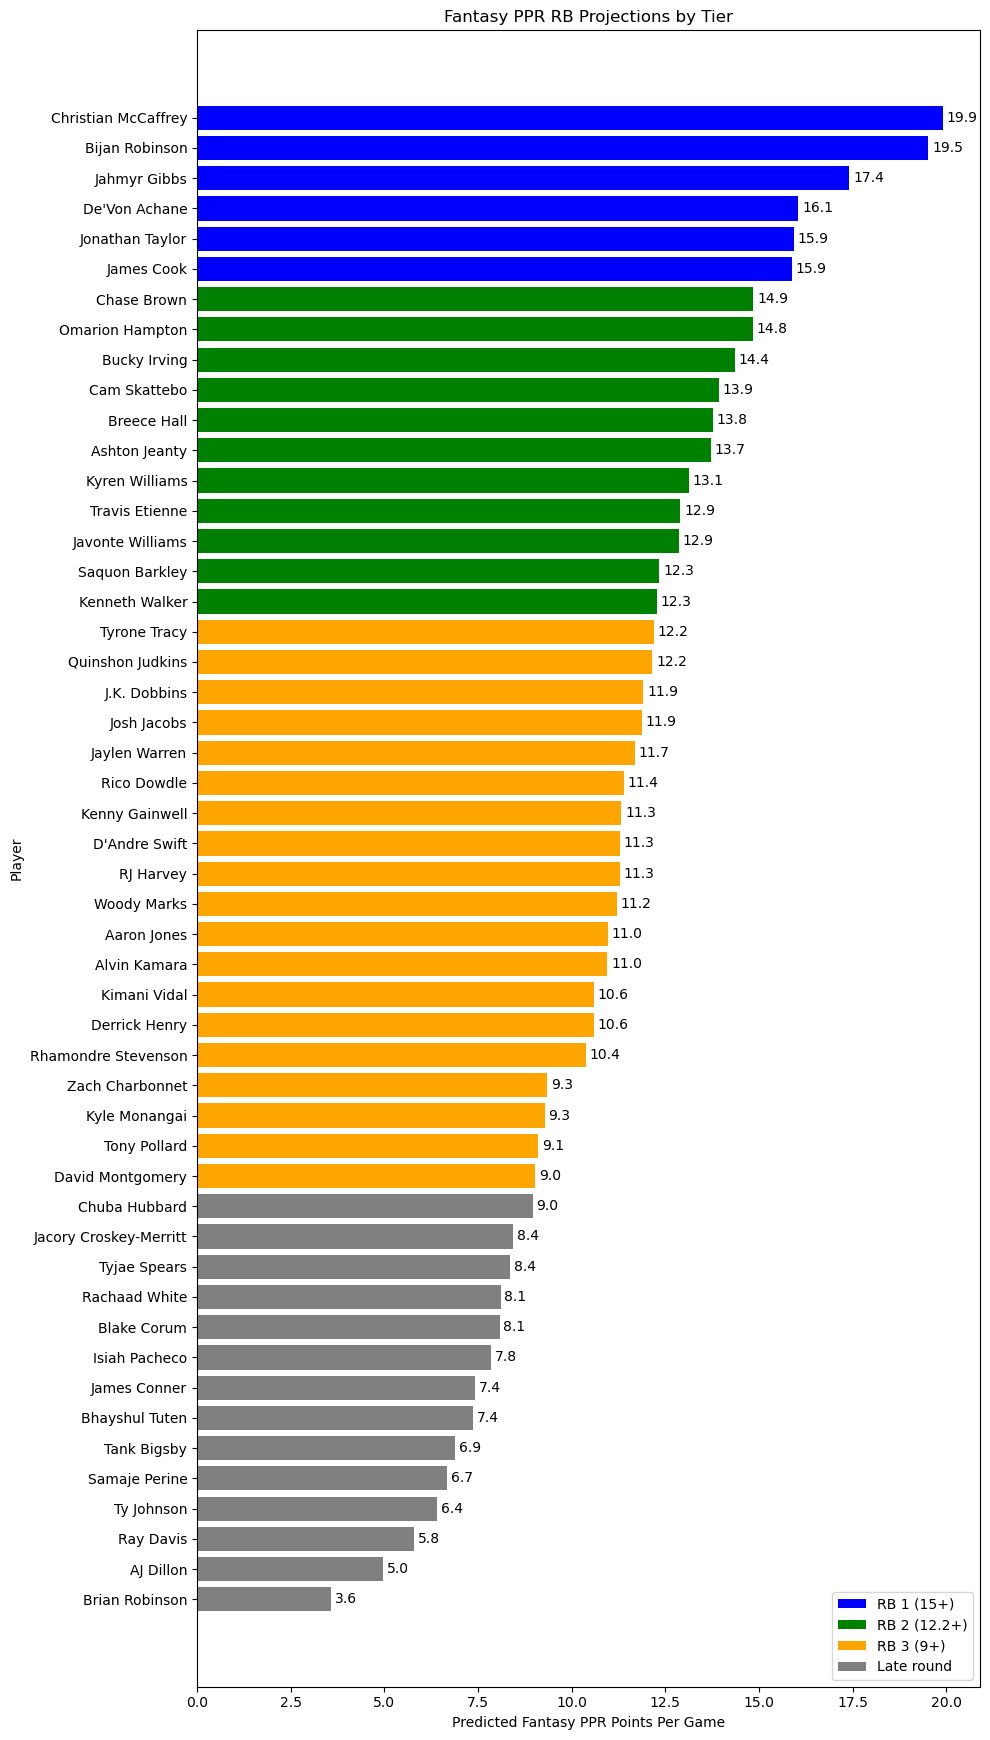

In [46]:
fig = plot_fantasy_tiers(
    projections,
    prediction_col="Predicted_Fantasy_PPR_PG",
    player_col="player_name"
)

fig.savefig(
    "../images/ridge_2026_rb_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

**A few surprises:**
- This Ridge model projects both Cam Skattebo and Tyrone Tracy to score over 12 points per game, which feels unlikely. This could be because Skattebo got hurt early in his rookie season, which brought down his season averages, overestimating the opportunity Tracy is likely to have this season.
- Derrick Henry is all the way down in RB3 territory despite a strong season last year. This may be a factor of age.

### XG Boost v1 (Full features)

In [47]:
train = final_rb[final_rb["season"].isin([2021, 2022, 2023, 2024])]
test = final_rb[final_rb["season"] == 2025]
projections = final_rb[final_rb["season"] == 2026]

In [48]:
# Use your longer predictor set
X_train = train[predictors]
X_test = test[predictors]

y_train = train[target]
y_test = test[target]

In [49]:
def find_best_params(X_train, y_train):
    # Parameter search space
    param_dist = {
        "n_estimators": [50, 100, 150, 200, 300, 500],
        "learning_rate": [0.01, 0.02, 0.03, 0.05, 0.1],
        "max_depth": [1, 2, 3, 4],
        "min_child_weight": [1, 3, 5, 10],
        "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "gamma": [0, 0.1, 0.3, 0.5, 1],
        "reg_alpha": [0, 0.5, 1, 2, 5],
        "reg_lambda": [1, 5, 10, 20, 50]
    }

    # Base model
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=42
    )

    # Random search
    random_search = RandomizedSearchCV(
        estimator=xgb,
        param_distributions=param_dist,
        n_iter=100,          # Number of parameter combinations to test
        scoring="r2",
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    # Fit
    random_search.fit(X_train, y_train)

    # Best results
    print("Best CV R²:", random_search.best_score_)
    print("\nBest Parameters:")
    print(random_search.best_params_)

In [50]:
find_best_params(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CV R²: 0.2587619827034442

Best Parameters:
{'subsample': 0.8, 'reg_lambda': 50, 'reg_alpha': 0.5, 'n_estimators': 300, 'min_child_weight': 10, 'max_depth': 1, 'learning_rate': 0.03, 'gamma': 0.3, 'colsample_bytree': 0.9}


In [51]:
# Create model
xgb_model_full = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=1,
    subsample=0.8,
    colsample_bytree=0.9,
    reg_alpha=0.5,
    reg_lambda=50,
    min_child_weight= 10,
    gamma=0.3,
    random_state=42
)

# Train
xgb_model_full.fit(
    X_train,
    y_train
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.3, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.03, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=1, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [52]:
# Predict
predictions = xgb_model_full.predict(X_test)

In [53]:
# Evaluate
print("MAE:", mean_absolute_error(y_test, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, predictions)))
print("R²:", r2_score(y_test, predictions))

MAE: 3.654880262520115
RMSE: 4.4863801582845095
R²: 0.3770510172526055


This with full features is worse than both our best linear regression and ridge models.

### XG Boost v2 (Narrowed features)

In [54]:
# Use your longer predictor set
X_train_2 = train[narrowed_predictors]
X_test_2 = test[narrowed_predictors]

y_train_2 = train[target]
y_test_2 = test[target]

In [55]:
find_best_params(X_train_2, y_train_2)

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best CV R²: 0.24458351148689564

Best Parameters:
{'subsample': 0.9, 'reg_lambda': 20, 'reg_alpha': 0, 'n_estimators': 50, 'min_child_weight': 10, 'max_depth': 1, 'learning_rate': 0.1, 'gamma': 0.1, 'colsample_bytree': 0.6}


In [56]:
# Create model
xgb_model_narrowed = XGBRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=1,
    subsample=0.9,
    colsample_bytree=0.6,
    reg_alpha=0,
    reg_lambda=20,
    min_child_weight= 10,
    gamma=0.1,
    random_state=42
)

# Train
xgb_model_narrowed.fit(
    X_train_2,
    y_train_2
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=1, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [57]:
predictions = xgb_model_narrowed.predict(X_test_2)

In [58]:
# Evaluate
print("MAE:", mean_absolute_error(y_test_2, predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test_2, predictions)))
print("R²:", r2_score(y_test_2, predictions))

MAE: 3.5979080424213317
RMSE: 4.405669482665482
R²: 0.3992633003433287


Slightly better than the first version of XG Boost but not better than our ridge regression model.

### 2026 Projections - XG Boost (Narrowed Features)

In [60]:
# Generate XGBoost predictions
projections["Predicted_Fantasy_PPR_PG"] = xgb_model_narrowed.predict(
    projections[narrowed_predictors]
)

# Sort by projected fantasy points
projections= projections.sort_values(
    "Predicted_Fantasy_PPR_PG",
    ascending=False
)

# Display results
print(
    projections[
        ["player_name", "season", "Predicted_Fantasy_PPR_PG"]
    ]
)

                player_name  season  Predicted_Fantasy_PPR_PG
199            Jahmyr Gibbs    2026                 16.186357
201     Christian McCaffrey    2026                 16.102322
205             Chase Brown    2026                 16.039944
202         Jonathan Taylor    2026                 15.893302
200          Bijan Robinson    2026                 15.696493
204           De'Von Achane    2026                 15.423571
213          Kyren Williams    2026                 15.174839
206              James Cook    2026                 15.142183
209         Omarion Hampton    2026                 15.078071
216            Cam Skattebo    2026                 14.898807
210             Josh Jacobs    2026                 14.847227
207           Derrick Henry    2026                 13.948456
214        Javonte Williams    2026                 13.861217
208          Saquon Barkley    2026                 12.876945
215          Travis Etienne    2026                 12.677540
203     

C:\Users\kevin\AppData\Local\Temp\ipykernel_23204\2649753750.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  projections["Predicted_Fantasy_PPR_PG"] = xgb_model_narrowed.predict(


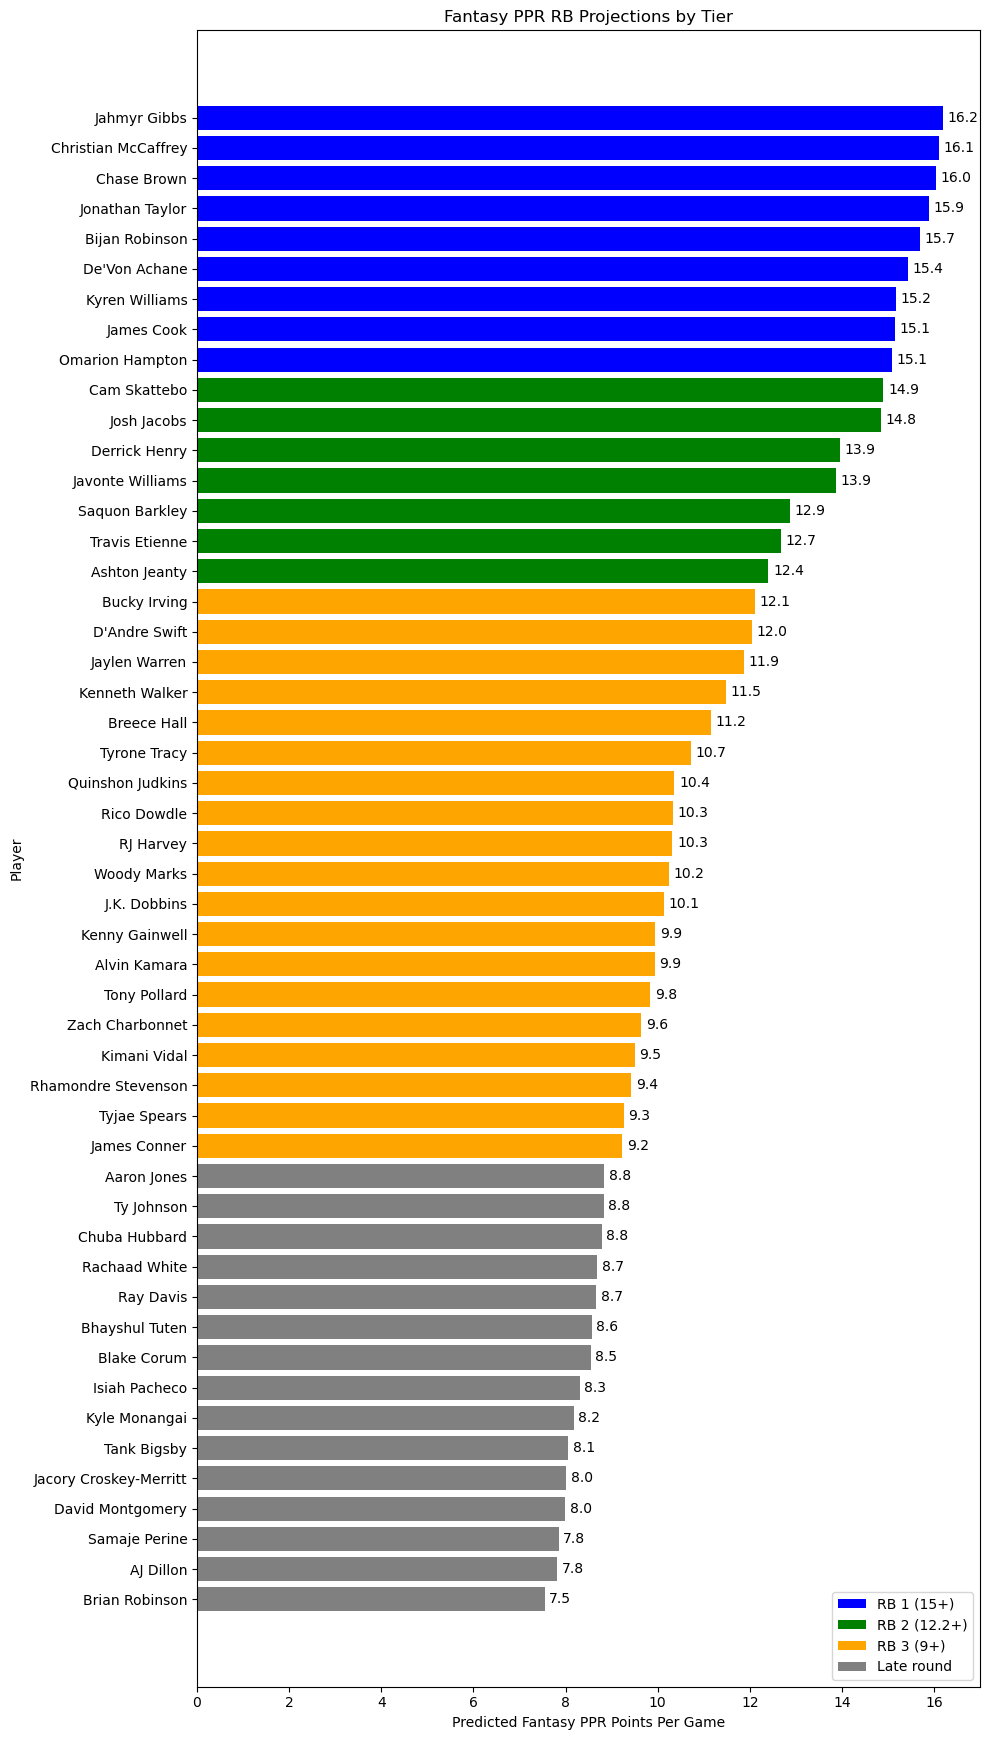

In [61]:
fig = plot_fantasy_tiers(
    projections,
    prediction_col="Predicted_Fantasy_PPR_PG",
    player_col="player_name"
)

fig.savefig(
    "../images/xgb_2026_rb_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

The projections here correct some surprises from the previous ridge model, such as moving Derrick Henry up to a RB2. Tyrone Tracy is also moved down below 11 points per game. Because there are some discrepancies in the projection, an ensemble model could once again be useful.

In [62]:
def find_xgb_feature_importance(predictors, xgb_model):
    importance = pd.DataFrame({
        "Feature": predictors,
        "Importance": xgb_model.feature_importances_
    })

    importance = importance.sort_values(
        "Importance",
        ascending=False
    )

    print(importance)

In [64]:
find_xgb_feature_importance(narrowed_predictors, xgb_model_narrowed)

                           Feature  Importance
4        Previous_rushing_yards_pg    0.191279
10  Previous_fantasy_points_ppr_pg    0.173865
3              Previous_carries_pg    0.138808
6           Previous_receptions_pg    0.125615
8      Previous_receiving_yards_pg    0.067821
22             Teammate_targets_pg    0.049972
16        QB_fantasy_points_ppr_pg    0.048490
15               QB_passing_tds_pg    0.042278
12               QB_completions_pg    0.040094
7              Previous_targets_pg    0.039381
21          Teammate_receptions_pg    0.030318
0                       player_age    0.030055
5          Previous_rushing_tds_pg    0.022023
24       Teammate_receiving_tds_pg    0.000000
23     Teammate_receiving_yards_pg    0.000000
19       Teammate_rushing_yards_pg    0.000000
25  Teammate_fantasy_points_ppr_pg    0.000000
20         Teammate_rushing_tds_pg    0.000000
13                  QB_attempts_pg    0.000000
18             Teammate_carries_pg    0.000000
17           

The feature importances here all showcase that the most important features are all the player's previous season performance. This is opposite what the linear model prioritized, so another good indicator to perform an ensemble model.

### Ensemble Model

In [65]:
# Ensemble weights
ridge_weight = 0.5
xgb_weight = 0.5

Although the Ridge model performed better, the R-squared scores were close so I will use even weights for simplicity.

In [66]:
ridge = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0))
])

ridge.fit(
    train[narrowed_predictors],
    train[target]
)

Pipeline(steps=[('scaler', StandardScaler()), ('model', Ridge())])

In [67]:
# Create model
xgb_model_narrowed = XGBRegressor(
    n_estimators=50,
    learning_rate=0.1,
    max_depth=1,
    subsample=0.9,
    colsample_bytree=0.6,
    reg_alpha=0,
    reg_lambda=20,
    min_child_weight= 10,
    gamma=0.1,
    random_state=42
)

# Train
xgb_model_narrowed.fit(
    X_train_2,
    y_train_2
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.6, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0.1, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=1, max_leaves=None,
             min_child_weight=10, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=50, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [68]:
ridge_pred = ridge.predict(test[narrowed_predictors]).flatten()
xgb_pred = xgb_model_narrowed.predict(X_test_2)

In [69]:
# Ensemble prediction
ensemble_pred = (
    ridge_weight * ridge_pred +
    xgb_weight * xgb_pred
)

In [70]:
# Create results dataframe
ensemble_results = test[["player_name", "season", "fantasy_points_ppr_pg"]].copy()

ensemble_results["Ridge Prediction"] = ridge_pred
ensemble_results["XGBoost Prediction"] = xgb_pred
ensemble_results["Ensemble Prediction"] = ensemble_pred

# Print predictions
print(ensemble_results.sort_values("Ensemble Prediction", ascending=False))

             player_name  season  fantasy_points_ppr_pg  Ridge Prediction  \
156        De'Von Achane    2025              20.175000         16.837177   
153         Jahmyr Gibbs    2025              21.582353         16.347527   
154       Saquon Barkley    2025              14.518750         16.562985   
166         Alvin Kamara    2025               9.154545         15.542585   
152       Bijan Robinson    2025              21.811765         15.427648   
161          Chase Brown    2025              16.623529         15.224975   
157      Jonathan Taylor    2025              21.311765         15.539397   
159          Josh Jacobs    2025              15.806667         13.728299   
165       Kenneth Walker    2025              11.288235         13.165277   
167         James Conner    2025              11.100000         13.150410   
164         Bucky Irving    2025              13.850000         15.946044   
160       Kyren Williams    2025              15.488235         13.780601   

In [71]:
# Evaluate ensemble
mae = mean_absolute_error(test[target], ensemble_pred)
mse = mean_squared_error(test[target], ensemble_pred)
rmse = np.sqrt(mse)
r2 = r2_score(test[target], ensemble_pred)

print("\nEnsemble Performance")
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R-squared: {r2:.3f}")


Ensemble Performance
MAE: 3.472
MSE: 18.341
RMSE: 4.283
R-squared: 0.432


This ensemble model actually has a slightly lower R-squared than our Ridge regression on our own. However, the mean absolute error (MAE) did improve from 3.493 to 3.472.

### 2026 Simulation and Projection - Ensemble Model

In [72]:
n_bootstrap = 1000

bootstrap_predictions = []

for i in range(n_bootstrap):

    # Bootstrap sample
    boot = resample(train, replace=True, random_state=i)

    # Fit both models
    ridge.fit(
        boot[narrowed_predictors],
        boot[target].values.ravel()
    )
    
    xgb_model_narrowed.fit(boot[narrowed_predictors], boot[target].values.ravel())

    # Predict 2026 rookies
    ridge_pred = ridge.predict(projections[narrowed_predictors]).flatten()
    xgb_pred = xgb_model_narrowed.predict(projections[narrowed_predictors])
    

    # Ensemble prediction
    ensemble_pred = (
        ridge_weight * ridge_pred +
        xgb_weight * xgb_pred
    )

    bootstrap_predictions.append(ensemble_pred)

bootstrap_predictions = np.array(bootstrap_predictions)

In [73]:
summary_ensemble = pd.DataFrame({
    "Name": projections["player_name"].values,
    "Mean": bootstrap_predictions.mean(axis=0),
    "Std": bootstrap_predictions.std(axis=0),
    "5th Percentile": np.percentile(bootstrap_predictions, 2.5, axis=0),
    "95th Percentile": np.percentile(bootstrap_predictions, 97.5, axis=0),
})

summary_ensemble["P(RB1)"] = (bootstrap_predictions >= 15).mean(axis=0)
summary_ensemble["P(RB2)"] = (
    ((bootstrap_predictions >= 12.2) &
     (bootstrap_predictions < 15))
).mean(axis=0)
summary_ensemble["P(RB3)"] = (
    ((bootstrap_predictions >= 9) &
     (bootstrap_predictions < 12.2))
).mean(axis=0)

summary_ensemble["P(Not Relevant)"] = (
    (bootstrap_predictions < 9)
).mean(axis=0)

summary_ensemble = summary_ensemble.sort_values("Mean", ascending=False)

In [74]:
summary_ensemble

,Name,Mean,Std,5th Percentile,95th Percentile,P(RB1),P(RB2),P(RB3),P(Not Relevant)
1,Christian McCaffrey,18.118900,1.165502,15.935197,20.266904,0.997,0.003,0.000,0.000
4,Bijan Robinson,17.578895,1.174687,15.146389,19.820875,0.985,0.015,0.000,0.000
0,Jahmyr Gibbs,16.743155,0.886469,14.919171,18.512878,0.969,0.031,0.000,0.000
3,Jonathan Taylor,15.730945,1.005408,13.784408,17.776977,0.767,0.233,0.000,0.000
5,De'Von Achane,15.576741,1.041416,13.621471,17.640496,0.722,0.277,0.001,0.000
7,James Cook,15.440435,1.042075,13.343666,17.393111,0.666,0.332,0.002,0.000
2,Chase Brown,15.215319,1.027710,13.143722,17.197265,0.602,0.393,0.005,0.000
8,Omarion Hampton,14.549279,0.927892,12.754665,16.313768,0.308,0.686,0.006,0.000
9,Cam Skattebo,14.047600,1.159073,11.754499,16.318640,0.208,0.736,0.056,0.000
6,Kyren Williams,13.925500,0.884117,12.341107,15.685752,0.111,0.868,0.021,0.000


In [75]:
summary_ensemble.to_csv('../outputs/ensemble_rbs_2026_prediction.csv', index=False)

In [ ]:
summary_ensemble = pd.read_csv('../outputs/ensemble_wrs_2026_prediction.csv')

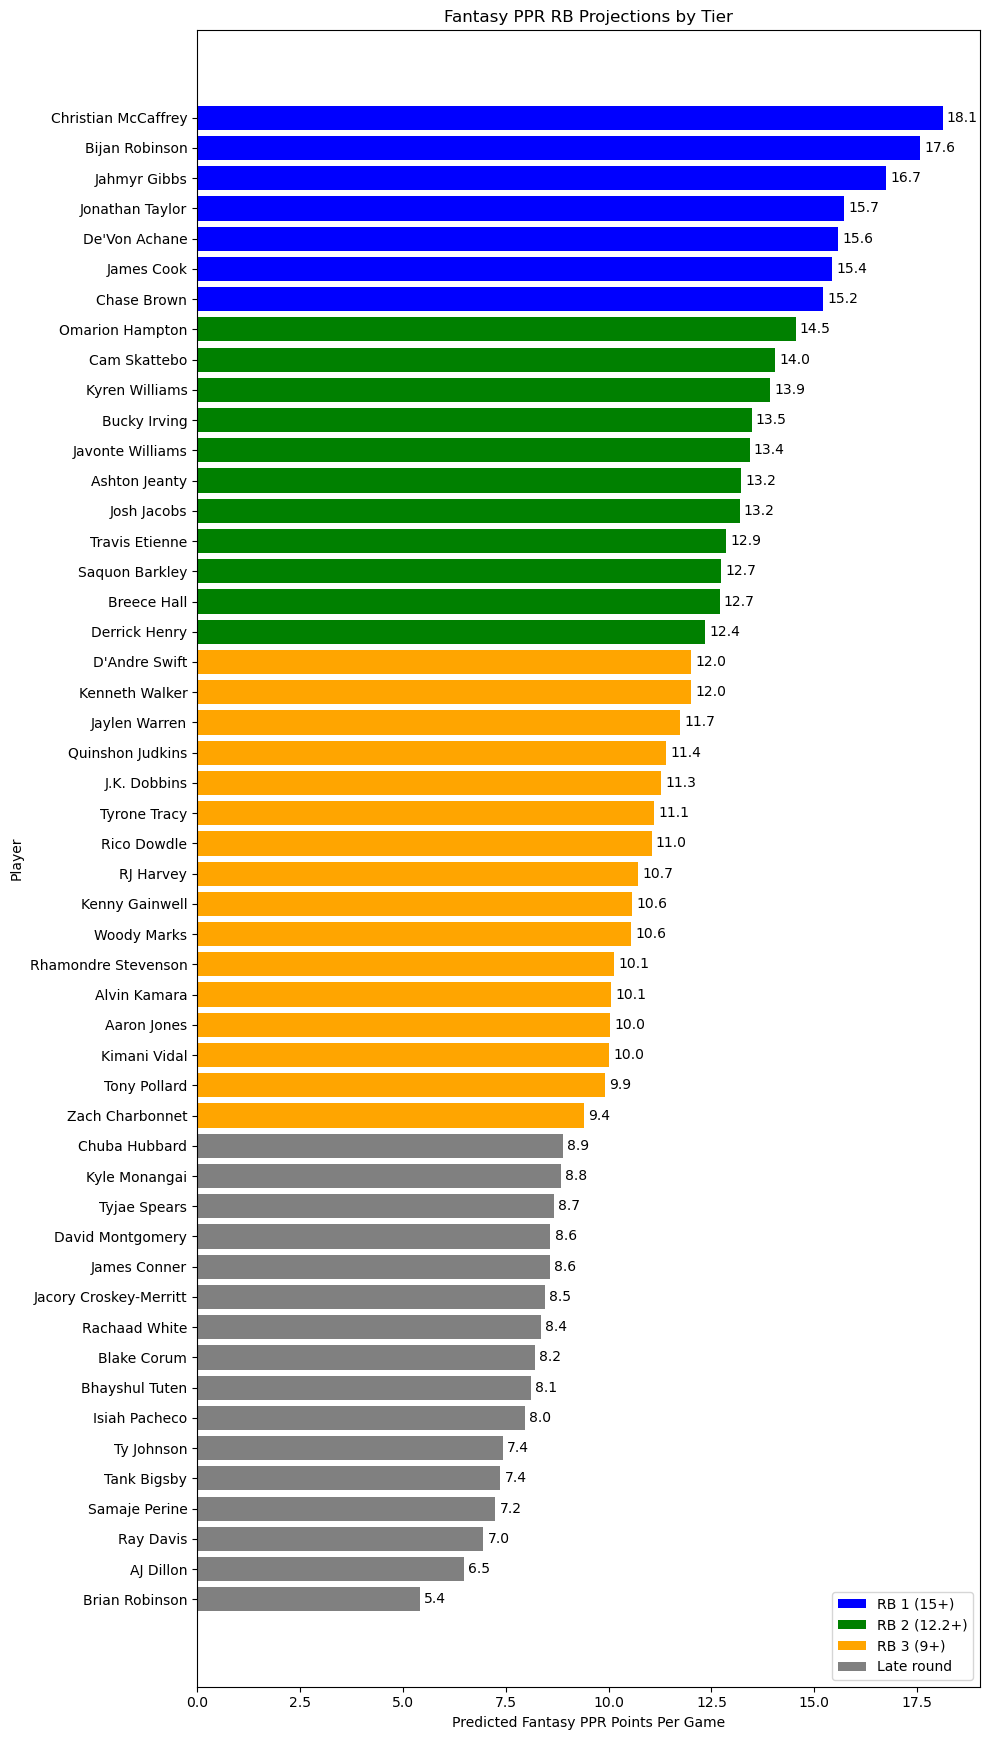

In [76]:
fig = plot_fantasy_tiers(
    summary_ensemble,
    prediction_col="Mean",
    player_col="Name"
)

fig.savefig(
    "../images/ensemble_2026_rb_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

In [77]:
def plot_prediction_intervals(summary):
    plot_df = summary.sort_values("Mean", ascending=True)

    # Distance from mean to interval bounds
    lower_error = plot_df["Mean"] - plot_df["5th Percentile"]
    upper_error = plot_df["95th Percentile"] - plot_df["Mean"]

    plt.figure(figsize=(10, max(6, len(plot_df) * 0.35)))

    plt.errorbar(
        plot_df["Mean"],
        plot_df["Name"],
        xerr=[lower_error, upper_error],
        fmt="o",
        capsize=4
    )

    plt.xlabel("Projected Fantasy PPR Points Per Game")
    plt.ylabel("Player")
    plt.title("2026 Rookie Fantasy Projections\nMean with 90% Prediction Interval")

    plt.grid(axis="x", alpha=.3)

    plt.tight_layout()
    return plt.gcf()

In [81]:
def plot_tier_probabilities(summary):

    # Sort from lowest to highest so the best players appear at the top
    plot_df = summary.sort_values("Mean", ascending=True)

    rb1 = plot_df["P(RB1)"] * 100
    rb2 = plot_df["P(RB2)"] * 100
    rb3 = plot_df["P(RB3)"] * 100
    irrelevant = plot_df["P(Not Relevant)"] * 100

    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.35)))

    # Stacked horizontal bars
    ax.barh(
        plot_df["Name"],
        rb1,
        label="RB1 (15+)",
        color="blue"
    )

    ax.barh(
        plot_df["Name"],
        rb2,
        left=rb1,
        label="RB2 (12.2-15)",
        color="green"
    )
    
    ax.barh(
        plot_df["Name"],
        rb3,
        left=rb1 + rb2,
        label="RB3 (9-12.2)",
        color="orange"
    )

    ax.barh(
        plot_df["Name"],
        irrelevant,
        left=rb1 + rb2 + rb3,
        label="Not Relevant (<10.5)",
        color="gray"
    )

    ax.set_xlabel("Simulation Probability (%)")
    ax.set_ylabel("Player")
    ax.set_xlim(0, 100)

    # Figure title
    fig.suptitle(
        "Probability of Falling into Each Fantasy Tier",
        fontsize=15,
        fontweight="bold",
        y=0.89
    )

    # Legend below title
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, 1.05),
        ncol=3,
        frameon=False
    )

    # Leave room for title and legend
    fig.tight_layout(rect=[0, 0, 1, 0.90])

    return plt.gcf()

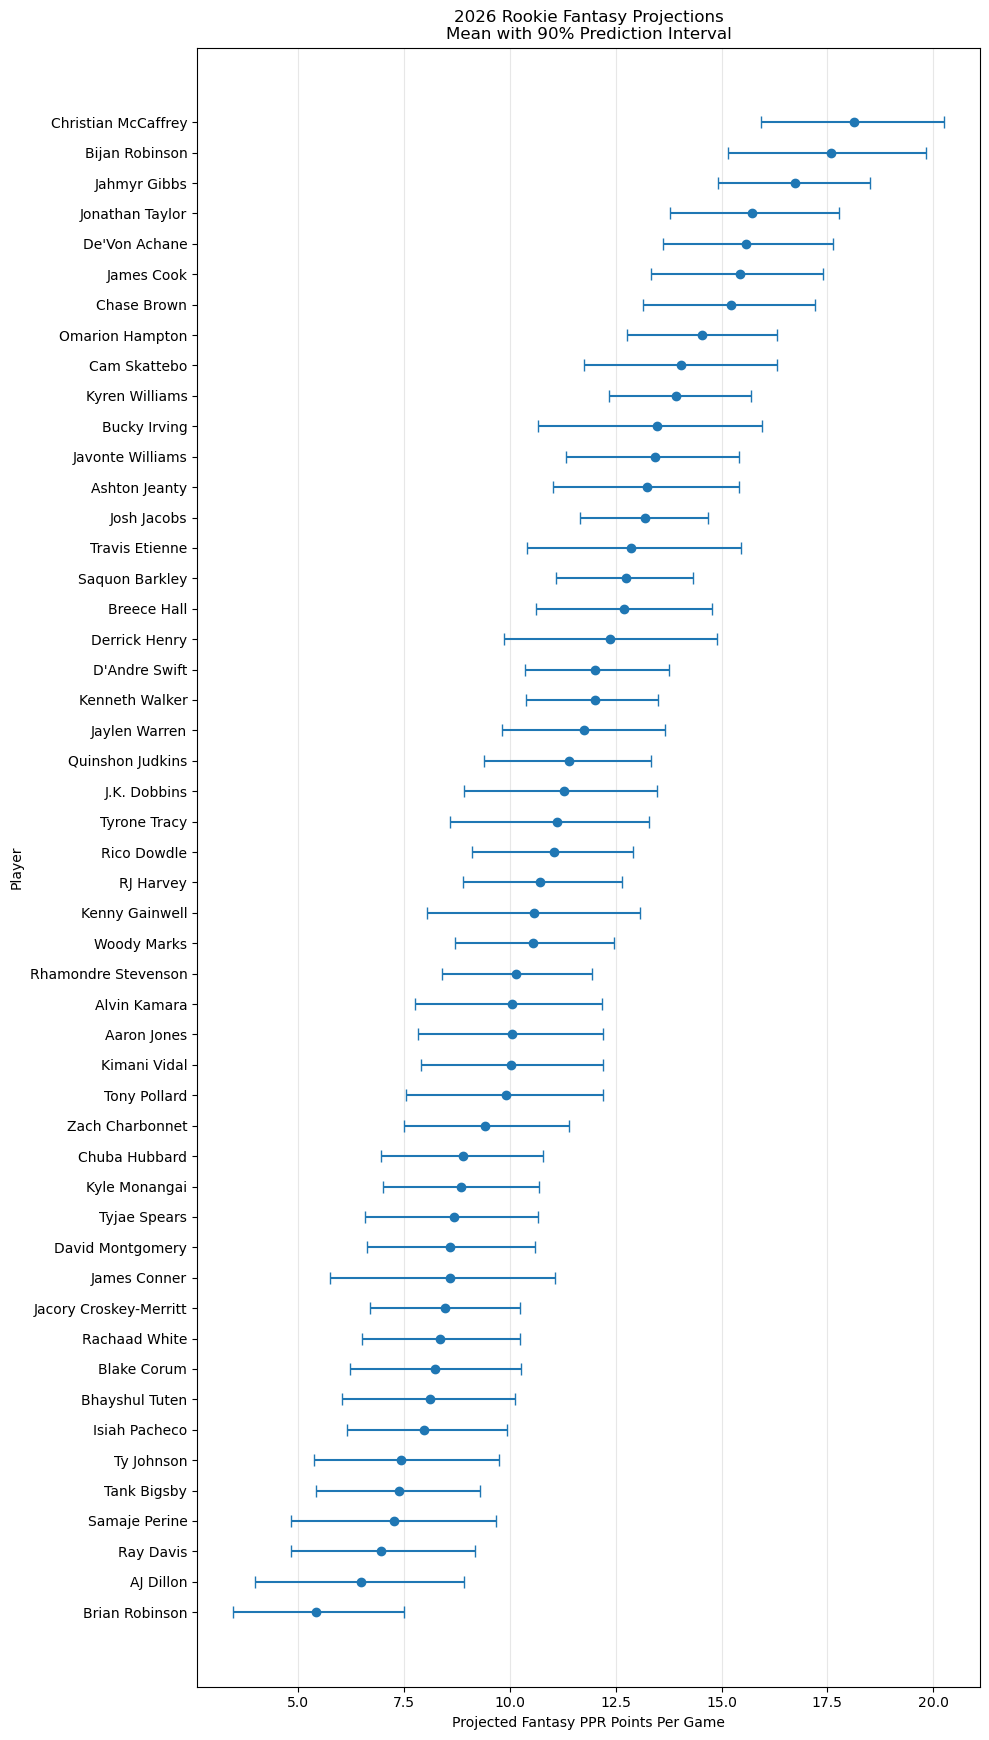

In [79]:
fig = plot_prediction_intervals(summary_ensemble)

fig.savefig(
    "../images/ensemble_2026_rb_prediction_intervals.png",
    dpi=300,
    bbox_inches="tight"
)

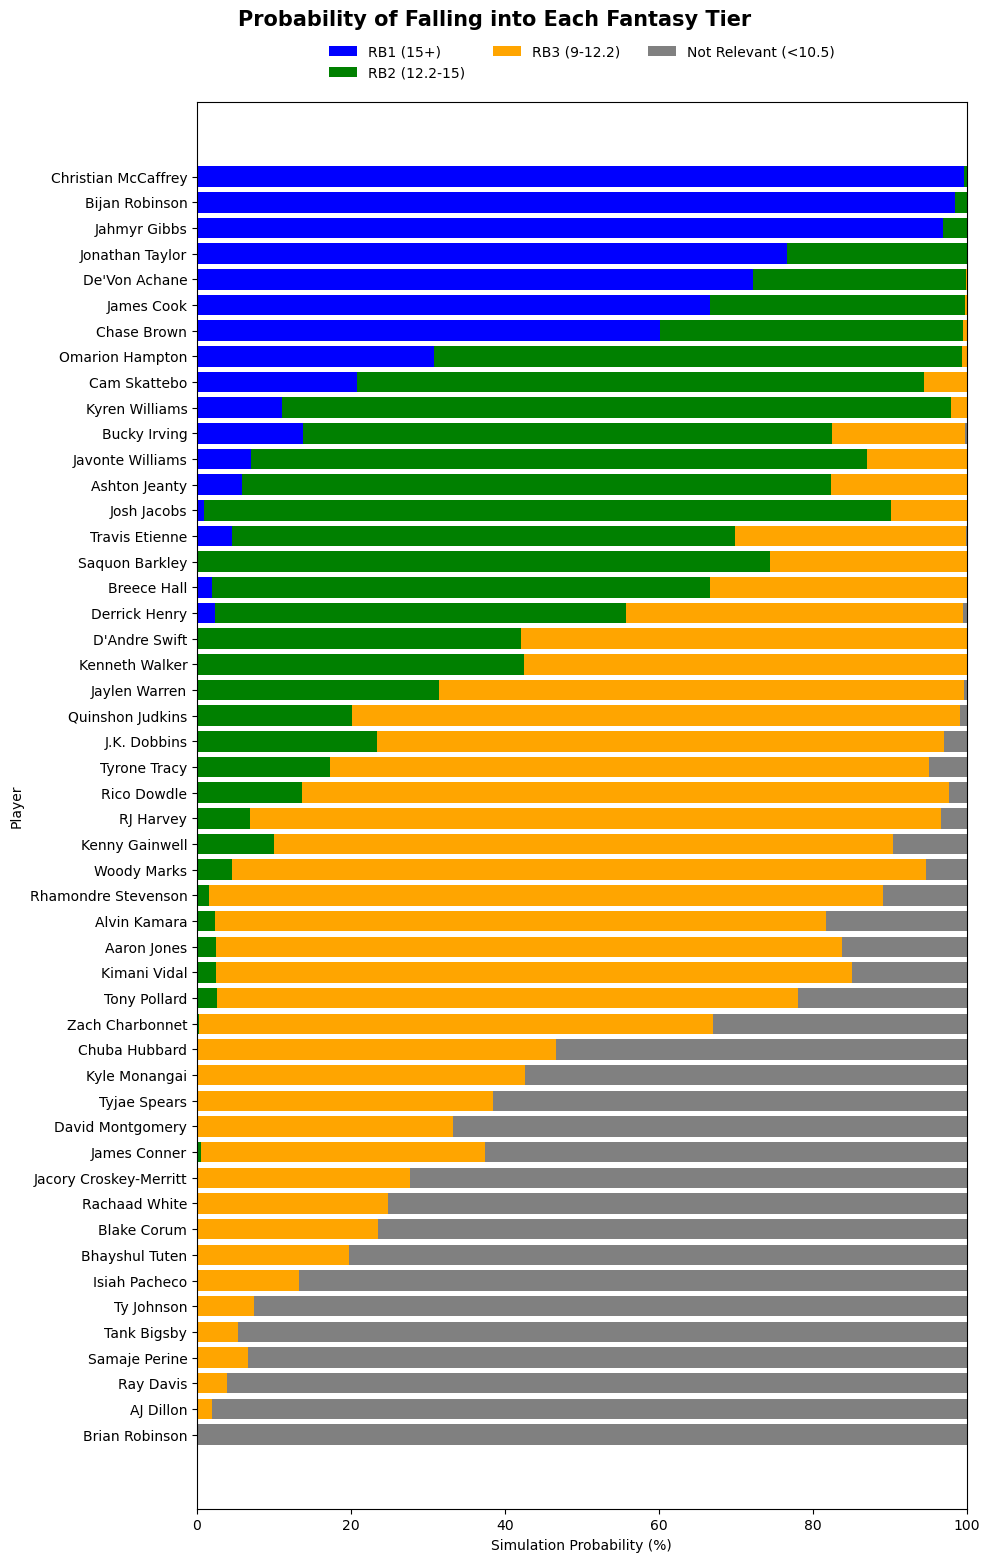

In [82]:
fig = plot_tier_probabilities(summary_ensemble)

fig.savefig(
    "../images/ensemble_2026_rb_tier_probabilities.png",
    dpi=300,
    bbox_inches="tight"
)

It seems like my ensemble model is very similar to just the 2025 PPR points per game finishes. In fact, the top 7 are the exact same. Some of those callouts earlier still exist with Derrick Henry substantially being lower than his finish.